In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [17]:
df.Purchased.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [18]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

count    400.000000
mean      37.655000
std       10.482877
min       18.000000
25%       29.750000
50%       37.000000
75%       46.000000
max       60.000000
Name: Age, dtype: float64


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: ylabel='Age'>

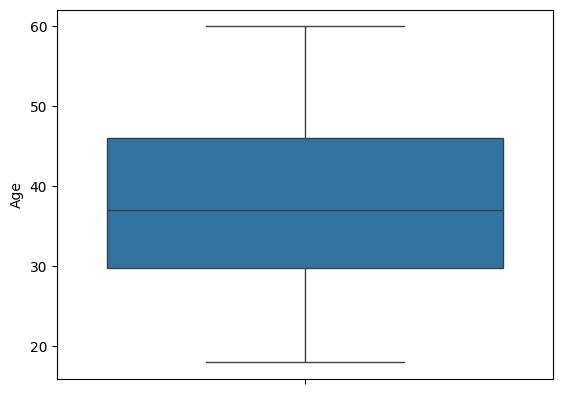

In [19]:
print(df["Age"].describe()) #Give statiscal data about Age like mean ,mode,median etc
sns.boxplot(data=df["Age"])#to anaylze and visulaize the dataset ,detect outliers etc

In [20]:
df.loc[df["Gender"] == "Male", "Gender"] = 0
df.loc[df["Gender"] == "Female", "Gender"] = 1

In [21]:
def min_max_normalize(feature): #function for future use
    df[feature] = (df[feature] - df[feature].min()) / (df[feature].max() - df[feature].min()) #mn-max formula

min_max_normalize("EstimatedSalary")
min_max_normalize("Age")

In [22]:
X = np.asarray(df.drop(["Purchased"], axis=1)) # 1 means column 0 means row
y = np.asarray(df["Purchased"])

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

model = LogisticRegression()
model.fit(X_train, y_train)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [32]:
y_pred = model.predict(X_test) # using testing data it will Predict

In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[79,  0],
       [41,  0]])

In [29]:
tp = ((y_pred == 1) & (y_test == 1)).sum() # will give true positive
tn = ((y_pred == 0) & (y_test == 0)).sum()  #True Negative
fp = ((y_pred == 1) & (y_test == 0)).sum()   #False Positive predicted 1 but actual; is 0
fn = ((y_pred == 0) & (y_test == 1)).sum()    #False Negativ
print(tp, tn, fp, fn)

0 79 0 41


In [30]:
recall = tp/(tp + fn)
accuracy = (tp + tn)/(tp + fp + tn + fn)
precision = tp / (tp + fp)
error = 1 - accuracy
f1 = (2 * recall * precision)/(recall + precision)

/tmp/ipykernel_6322/1379182529.py:3: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
